In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from model import LSTM
lookback = 7

data     = pd.read_csv('AMZN_data_for_lstm.csv')
dataAMZN = pd.read_csv('AMZN.csv')
data

,Close,Close(t-1),Close(t-2),Close(t-3),Close(t-4),Close(t-5),Close(t-6),Close(t-7)
0,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417,0.086458,0.097917
1,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417,0.086458
2,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771,0.085417
3,0.075000,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354,0.081771
4,0.075521,0.075000,0.075260,0.076563,0.079167,0.075000,0.069792,0.071354
...,...,...,...,...,...,...,...,...
6504,102.000000,100.250000,97.239998,98.040001,98.129997,98.709999,98.699997,100.610001
6505,103.290001,102.000000,100.250000,97.239998,98.040001,98.129997,98.709999,98.699997
6506,102.410004,103.290001,102.000000,100.250000,97.239998,98.040001,98.129997,98.709999
6507,103.949997,102.410004,103.290001,102.000000,100.250000,97.239998,98.040001,98.129997


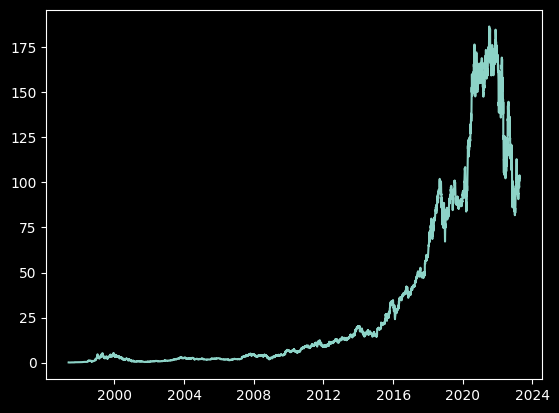

In [2]:
dataAMZN['Date'] = pd.to_datetime(dataAMZN['Date'])
plt.plot(dataAMZN['Date'], dataAMZN['Close'])

In [3]:
df_as_np = data.to_numpy()
df_as_np

array([[7.91670000e-02, 7.50000000e-02, 6.97920000e-02, ...,
        8.54170000e-02, 8.64580000e-02, 9.79170000e-02],
       [7.65630000e-02, 7.91670000e-02, 7.50000000e-02, ...,
        8.17710000e-02, 8.54170000e-02, 8.64580000e-02],
       [7.52600000e-02, 7.65630000e-02, 7.91670000e-02, ...,
        7.13540000e-02, 8.17710000e-02, 8.54170000e-02],
       ...,
       [1.02410004e+02, 1.03290001e+02, 1.02000000e+02, ...,
        9.80400010e+01, 9.81299970e+01, 9.87099990e+01],
       [1.03949997e+02, 1.02410004e+02, 1.03290001e+02, ...,
        9.72399980e+01, 9.80400010e+01, 9.81299970e+01],
       [1.01099998e+02, 1.03949997e+02, 1.02410004e+02, ...,
        1.00250000e+02, 9.72399980e+01, 9.80400010e+01]])

In [4]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(-1, 1))
df_as_np = scaler.fit_transform(df_as_np)
df_as_np

array([[-0.99991063, -0.99995531, -1.        , ..., -0.99983244,
        -0.99982128, -0.99969839],
       [-0.99993855, -0.99991063, -0.99994415, ..., -0.99987154,
        -0.99983244, -0.99982128],
       [-0.99995253, -0.99993855, -0.99989946, ..., -0.99998325,
        -0.99987154, -0.99983244],
       ...,
       [ 0.09747299,  0.10690997,  0.09308121, ...,  0.0506149 ,
         0.05158   ,  0.05779984],
       [ 0.11398769,  0.09747299,  0.10691495, ...,  0.04203581,
         0.0506149 ,  0.05158   ],
       [ 0.08342464,  0.11398769,  0.09747802, ...,  0.07431453,
         0.04203581,  0.0506149 ]])

In [5]:
X = df_as_np[:,1:]
Y = df_as_np[:,0 ]
X.shape , Y.shape

((6509, 7), (6509,))

In [6]:
from copy import deepcopy
X = deepcopy(np.flip(X, axis=1))
X

array([[-0.99969839, -0.99982128, -0.99983244, ..., -0.99998325,
        -1.        , -0.99995531],
       [-0.99982128, -0.99983244, -0.99987154, ..., -1.        ,
        -0.99994415, -0.99991063],
       [-0.99983244, -0.99987154, -0.99998325, ..., -0.99994415,
        -0.99989946, -0.99993855],
       ...,
       [ 0.05779984,  0.05158   ,  0.0506149 , ...,  0.07431453,
         0.09308121,  0.10690997],
       [ 0.05158   ,  0.0506149 ,  0.04203581, ...,  0.09308121,
         0.10691495,  0.09747299],
       [ 0.0506149 ,  0.04203581,  0.07431453, ...,  0.10691495,
         0.09747802,  0.11398769]])

In [7]:
n_splite = int(len(X)*0.95)
X_train = X[:n_splite]
X_test  = X[n_splite:]
Y_train = Y[:n_splite]
Y_test  = Y[n_splite:]
X_train.shape , X_test.shape , Y_train.shape , Y_test.shape 

((6183, 7), (326, 7), (6183,), (326,))

In [8]:
X_train = X_train.reshape((-1, lookback, 1))
X_test = X_test.reshape((-1, lookback, 1))

Y_train = Y_train.reshape((-1, 1))
Y_test  = Y_test.reshape((-1, 1))

X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((6183, 7, 1), (326, 7, 1), (6183, 1), (326, 1))

# Training

In [9]:
X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test  = torch.tensor(X_test).float()
Y_test  = torch.tensor(Y_test).float()

from torch.utils.data import Dataset

class TimeSeriesDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.Y[i]

train_dataset = TimeSeriesDataset(X_train, Y_train)
test_dataset  = TimeSeriesDataset(X_test , Y_test )
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

(torch.Size([6183, 7, 1]),
 torch.Size([326, 7, 1]),
 torch.Size([6183, 1]),
 torch.Size([326, 1]))

In [10]:
from torch.utils.data import DataLoader
batch_size = 16
device = 'cuda'
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True )
test_loader  = DataLoader(test_dataset ,batch_size=batch_size,shuffle=False)


for _ , batch in enumerate (train_loader) :
    x_batch , y_batch = batch[0].to(device) , batch[1].to(device)
    print(x_batch.shape , y_batch.shape)
    break

torch.Size([16, 7, 1]) torch.Size([16, 1])


In [11]:
model = LSTM(1, 4, 1)
model.to(device)
model

LSTM(
  (lstm): LSTM(1, 4, batch_first=True)
  (fc): Linear(in_features=4, out_features=1, bias=True)
)

In [13]:
num_epoch = 10
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters() , lr=0.001)



def train_one_epoch():
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    running_loss = 0.0

    for batch_index, batch in enumerate(train_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        output = model(x_batch)
        loss = loss_function(output, y_batch)
        running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_index % 100 == 99:  
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.3f}'.format(batch_index+1,
                                                    avg_loss_across_batches))
            running_loss = 0.0
    print()

def validate_one_epoch():
    model.train(False)
    running_loss = 0.0

    for batch_index, batch in enumerate(test_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        with torch.no_grad():
            output = model(x_batch)
            loss = loss_function(output, y_batch)
            running_loss += loss.item()

    avg_loss_across_batches = running_loss / len(test_loader)

    print('Val Loss: {0:.3f}'.format(avg_loss_across_batches))
    print('=================================')
    print()





for epoch in range(num_epoch):
    train_one_epoch()
    validate_one_epoch()

Epoch: 1
Batch 100, Loss: 0.140
Batch 200, Loss: 0.052
Batch 300, Loss: 0.020

Val Loss: 0.023

Epoch: 2
Batch 100, Loss: 0.005
Batch 200, Loss: 0.003
Batch 300, Loss: 0.002

Val Loss: 0.009

Epoch: 3
Batch 100, Loss: 0.001
Batch 200, Loss: 0.000
Batch 300, Loss: 0.000

Val Loss: 0.005

Epoch: 4
Batch 100, Loss: 0.000
Batch 200, Loss: 0.000
Batch 300, Loss: 0.000

Val Loss: 0.005

Epoch: 5
Batch 100, Loss: 0.000
Batch 200, Loss: 0.000
Batch 300, Loss: 0.000

Val Loss: 0.005

Epoch: 6
Batch 100, Loss: 0.000
Batch 200, Loss: 0.000
Batch 300, Loss: 0.000

Val Loss: 0.005

Epoch: 7
Batch 100, Loss: 0.000
Batch 200, Loss: 0.000
Batch 300, Loss: 0.000

Val Loss: 0.004

Epoch: 8
Batch 100, Loss: 0.000
Batch 200, Loss: 0.000
Batch 300, Loss: 0.000

Val Loss: 0.004

Epoch: 9
Batch 100, Loss: 0.000
Batch 200, Loss: 0.000
Batch 300, Loss: 0.000

Val Loss: 0.004

Epoch: 10
Batch 100, Loss: 0.000
Batch 200, Loss: 0.000
Batch 300, Loss: 0.000

Val Loss: 0.004



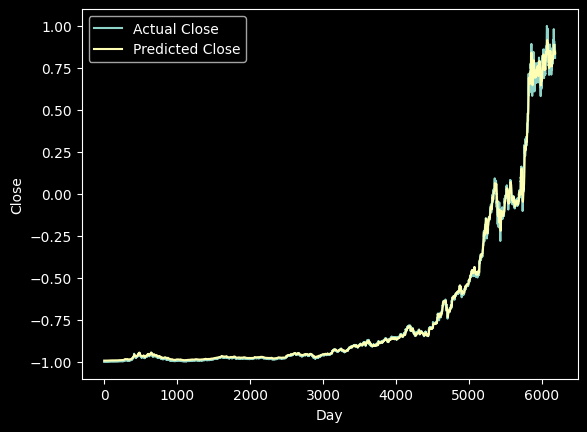

In [14]:
with torch.no_grad():
    predicted = model(X_train.to(device)).to('cpu').numpy()

plt.plot(Y_train, label='Actual Close')
plt.plot(predicted, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()

# Show Result & Validation

In [19]:
train_predictions = predicted.flatten()
dummies = np.zeros((X_train.shape[0], lookback+1))

dummies[:, 0] = train_predictions
dummies = scaler.inverse_transform(dummies)
train_predictions = deepcopy(dummies[:, 0])
 
dummies = np.zeros((X_train.shape[0], lookback+1))
dummies[:, 0] = Y_train.flatten()
dummies = scaler.inverse_transform(dummies)
new_y_train = deepcopy(dummies[:, 0])

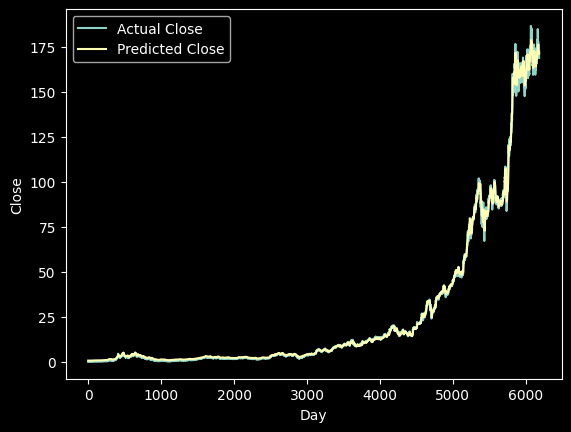

In [20]:
plt.plot(new_y_train, label='Actual Close')
plt.plot(train_predictions, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()

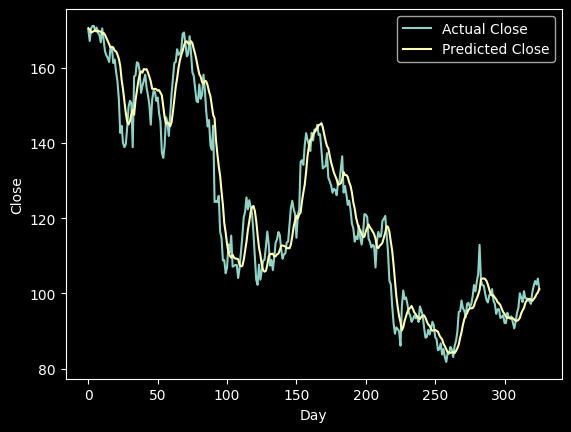

In [21]:
test_predictions = model(X_test.to(device)).detach().cpu().numpy().flatten()

dummies = np.zeros((X_test.shape[0], lookback+1))
dummies[:, 0] = test_predictions
dummies = scaler.inverse_transform(dummies)

test_predictions = deepcopy(dummies[:, 0])
 

dummies = np.zeros((X_test.shape[0], lookback+1))
dummies[:, 0] = Y_test.flatten()
dummies = scaler.inverse_transform(dummies)
new_y_test = deepcopy(dummies[:, 0])

plt.plot(new_y_test, label='Actual Close')
plt.plot(test_predictions, label='Predicted Close')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()

In [ ]:
def predict_next(values):
    model.eval()
    with torch.no_grad():
        dummy = np.zeros((1, lookback + 1))  
        dummy[0, 1:] = values[::-1] 

        scaled = scaler.transform(dummy)
        scaled_input = scaled[0, 1:] 
        input_seq = torch.tensor(scaled_input, dtype=torch.float32).view(1, lookback, 1).to(device)
        scaled_output = model(input_seq).cpu().numpy()

        dummy_out = np.zeros((1, lookback + 1))
        dummy_out[0, 0] = scaled_output
        actual_output = scaler.inverse_transform(dummy_out)[0, 0]

    return actual_output

user_input = [221.47, 221.30, 221.69, 221.69, 221.69, 223.13, 222.31]
predicted_value = predict_next(user_input)
print(f"Input {user_input}  Predict : {predicted_value:.4f}") # 224.56


輸入 [221.47, 221.3, 221.69, 221.69, 221.69, 223.13, 222.31] 預測結果為: 192.4055
